In [ ]:
!pip install requests beautifulsoup4 pandas pillow tqdm

In [ ]:
import os

os.makedirs("data/images", exist_ok=True)
os.makedirs("data/raw", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [ ]:
SEARCH_QUERIES = {
    "tshirt": [
        "men t shirt",
        "women t shirt",
        "kids t shirt",
        "oversized t shirt",
        "printed t shirt"
    ],
    "polo": [
        "men polo shirt",
        "women polo shirt",
        "kids polo shirt"
    ],
    "shirt": [
        "men formal shirt",
        "women shirt",
        "kids shirt"
    ],
    "jeans": [
        "men jeans",
        "women jeans",
        "kids jeans"
    ],
    "chinos": [
        "men chinos",
        "women chinos"
    ],
    "joggers": [
        "men joggers",
        "women joggers",
        "kids joggers"
    ],
    "shorts": [
        "men shorts",
        "women shorts",
        "kids shorts"
    ],
    "hoodie": [
        "men hoodie",
        "women hoodie",
        "kids hoodie"
    ],
    "jacket": [
        "men jacket",
        "women jacket",
        "kids jacket"
    ],
    "sneakers": [
        "men sneakers",
        "women sneakers",
        "kids sneakers"
    ],
    "boots": [
        "men boots",
        "women boots"
    ],
    "belt": [
        "men belt",
        "women belt"
    ],
    "watch": [
        "men watch",
        "women watch",
        "kids watch"
    ],
    "cap": [
        "men cap",
        "women cap",
        "kids cap"
    ]
}

In [ ]:
# ============================================
# STEP 4: Imports
# ============================================
import os
import re
import time
import random
import requests
import pandas as pd
from urllib.parse import quote_plus
from bs4 import BeautifulSoup
from tqdm import tqdm
from PIL import Image
from io import BytesIO

In [ ]:
# ============================================
# STEP 5: Headers (لتقليل احتمال الحظر)
# ============================================
HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9"
}

In [ ]:
# ============================================
# STEP 6: Helper Functions
# ============================================

def clean_text(text):
    if text is None:
        return None
    return re.sub(r"\s+", " ", str(text)).strip()


def safe_filename(text, max_len=80):
    text = re.sub(r"[^a-zA-Z0-9_-]+", "_", text)
    return text[:max_len].strip("_")


def extract_color(title):
    COMMON_COLORS = [
        "black", "white", "blue", "navy", "red", "green",
        "gray", "grey", "brown", "beige", "pink", "yellow",
        "orange", "purple", "maroon", "olive", "khaki"
    ]
    title_lower = title.lower()
    for color in COMMON_COLORS:
        if color in title_lower:
            return color
    return None


def extract_size(title):
    SIZE_PATTERNS = [
        r"\bXS\b", r"\bS\b", r"\bM\b", r"\bL\b", r"\bXL\b",
        r"\bXXL\b", r"\bXXXL\b", r"\b\d{2}\b"
    ]
    for pattern in SIZE_PATTERNS:
        match = re.search(pattern, title, re.IGNORECASE)
        if match:
            return match.group(0).upper()
    return None

In [ ]:
# ============================================
# STEP 7: Download Image
# ============================================

def download_image(url, save_path):
    try:
        response = requests.get(url, headers=HEADERS, timeout=20)
        response.raise_for_status()

        image = Image.open(BytesIO(response.content)).convert("RGB")
        image = image.resize((224, 224))
        image.save(save_path, quality=95)

        return True
    except Exception:
        return False

In [ ]:
# ============================================
# STEP 8: Scrape One Amazon Search Page
# ============================================

def scrape_amazon_category(category, query, max_pages=3):
    results = []
    category_folder = f"data/images/{category}"
    os.makedirs(category_folder, exist_ok=True)

    for page in range(1, max_pages + 1):
        encoded_query = quote_plus(query)
        url = f"https://www.amazon.eg/s?k={encoded_query}&page={page}"

        print(f"Scraping {category} | Page {page}")

        try:
            response = requests.get(url, headers=HEADERS, timeout=30)
            response.raise_for_status()
        except Exception as e:
            print("Request failed:", e)
            continue

        soup = BeautifulSoup(response.text, "html.parser")
        items = soup.select("div.s-result-item[data-component-type='s-search-result']")

        for idx, item in enumerate(items):
            try:
                title_el = item.select_one("h2 span")
                image_el = item.select_one("img.s-image")
                price_el = item.select_one(".a-price .a-offscreen")
                rating_el = item.select_one("span.a-icon-alt")
                link_el = item.select_one("h2 a")

                if not title_el or not image_el:
                    continue

                title = clean_text(title_el.get_text())
                image_url = image_el.get("src")
                price = clean_text(price_el.get_text()) if price_el else None
                rating = clean_text(rating_el.get_text()) if rating_el else None

                product_url = None
                if link_el and link_el.get("href"):
                    product_url = "https://www.amazon.eg" + link_el["href"]

                color = extract_color(title)
                size = extract_size(title)

                filename = safe_filename(f"{category}_{page}_{idx}.jpg")
                local_path = os.path.join(category_folder, filename)

                downloaded = download_image(image_url, local_path)
                if not downloaded:
                    local_path = None

                results.append({
                    "title": title,
                    "category": category,
                    "search_query": query,
                    "price": price,
                    "rating": rating,
                    "color": color,
                    "size": size,
                    "image_url": image_url,
                    "product_url": product_url,
                    "local_image_path": local_path
                })

            except Exception:
                continue

        time.sleep(random.uniform(2, 5))

    return results

In [ ]:
all_products = []

for category, queries in SEARCH_QUERIES.items():
    for query in queries:

        products = scrape_amazon_category(
            category=category,
            query=query,
            max_pages=30
        )

        all_products.extend(products)

        print(f"{category} | {query}: {len(products)} products collected")
        print("-" * 50)
        pd.DataFrame(all_products).to_csv("data/raw/amazon_fashion.csv", index=False, encoding="utf-8-sig")

Scraping tshirt | Page 1
Scraping tshirt | Page 2
Scraping tshirt | Page 3
Scraping tshirt | Page 4
Scraping tshirt | Page 5
Scraping tshirt | Page 6
Scraping tshirt | Page 7
Scraping tshirt | Page 8
Scraping tshirt | Page 9
Scraping tshirt | Page 10
Scraping tshirt | Page 11
Scraping tshirt | Page 12
Scraping tshirt | Page 13
Scraping tshirt | Page 14
Scraping tshirt | Page 15
Scraping tshirt | Page 16
Scraping tshirt | Page 17
Scraping tshirt | Page 18
Scraping tshirt | Page 19
Scraping tshirt | Page 20
Scraping tshirt | Page 21
Scraping tshirt | Page 22
Scraping tshirt | Page 23
Scraping tshirt | Page 24
Scraping tshirt | Page 25
Scraping tshirt | Page 26
Scraping tshirt | Page 27
Scraping tshirt | Page 28
Scraping tshirt | Page 29
Scraping tshirt | Page 30
tshirt | men t shirt: 366 products collected
--------------------------------------------------
Scraping tshirt | Page 1
Scraping tshirt | Page 2
Scraping tshirt | Page 3
Scraping tshirt | Page 4
Scraping tshirt | Page 5
Scraping

In [ ]:
df = pd.DataFrame(all_products)

df.drop_duplicates(subset=["title", "image_url"], inplace=True)
print("Total products before deduplication:", len(all_products))
print("Total products after deduplication:", len(df))

df.to_csv("data/raw/amazon_fashion.csv", index=False, encoding="utf-8-sig")
df.head()

Total products before deduplication: 14528
Total products after deduplication: 8739


,title,category,search_query,price,rating,color,size,image_url,product_url,local_image_path
0,Levi's,tshirt,men t shirt,EGP 467.69,5.0 out of 5 stars,None,S,https://m.media-amazon.com/images/I/51k5syalPO...,None,None
1,LC WAIKIKI,tshirt,men t shirt,EGP 499.00,4.0 out of 5 stars,None,None,https://m.media-amazon.com/images/I/71gX6mc71+...,None,None
2,Levi's,tshirt,men t shirt,"EGP 1,341.30",5.0 out of 5 stars,None,S,https://m.media-amazon.com/images/I/71lHF+hjYn...,None,None
3,Levi's,tshirt,men t shirt,"EGP 1,149.13",4.2 out of 5 stars,None,S,https://m.media-amazon.com/images/I/71aAll1RIy...,None,None
4,JACK & JONES,tshirt,men t shirt,EGP 593.10,4.5 out of 5 stars,None,None,https://m.media-amazon.com/images/I/61pe-t4xSL...,None,None


In [ ]:
import shutil
shutil.make_archive("data/images_backup", "zip", "data/images")
print("Done! images_backup.zip is ready to download.")

Done! images_backup.zip is ready to download.


In [ ]:
import pandas as pd
df = pd.read_csv("data/raw/amazon_fashion.csv")
print(df.shape)
df.head()

(8739, 10)


,title,category,search_query,price,rating,color,size,image_url,product_url,local_image_path
0,Levi's,tshirt,men t shirt,EGP 467.69,5.0 out of 5 stars,NaN,S,https://m.media-amazon.com/images/I/51k5syalPO...,NaN,NaN
1,LC WAIKIKI,tshirt,men t shirt,EGP 499.00,4.0 out of 5 stars,NaN,NaN,https://m.media-amazon.com/images/I/71gX6mc71+...,NaN,NaN
2,Levi's,tshirt,men t shirt,"EGP 1,341.30",5.0 out of 5 stars,NaN,S,https://m.media-amazon.com/images/I/71lHF+hjYn...,NaN,NaN
3,Levi's,tshirt,men t shirt,"EGP 1,149.13",4.2 out of 5 stars,NaN,S,https://m.media-amazon.com/images/I/71aAll1RIy...,NaN,NaN
4,JACK & JONES,tshirt,men t shirt,EGP 593.10,4.5 out of 5 stars,NaN,NaN,https://m.media-amazon.com/images/I/61pe-t4xSL...,NaN,NaN


In [ ]:
import pandas as pd
from PIL import Image
from io import BytesIO
import requests
import os

df = pd.read_csv("data/raw/amazon_fashion.csv")

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
}

for idx, row in df.iterrows():
    try:
        category = row["category"]
        image_url = row["image_url"]

        folder = f"data/images/{category}"
        os.makedirs(folder, exist_ok=True)

        save_path = f"{folder}/{idx}.jpg"

        response = requests.get(image_url, headers=HEADERS, timeout=20)
        image = Image.open(BytesIO(response.content)).convert("RGB")
        image = image.resize((224, 224))
        image.save(save_path, quality=95)

    except Exception:
        continue

print("Done!")

Done!


In [ ]:
import os

total = 0
for folder in os.listdir("data/images"):
    folder_path = f"data/images/{folder}"
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"{folder}: {count} images")
        total += count

print(f"\nTotal images: {total}")

jeans: 656 images
polo: 610 images
cap: 623 images
jacket: 692 images
joggers: 753 images
shorts: 652 images
tshirt: 1031 images
belt: 439 images
shirt: 627 images
sneakers: 651 images
watch: 684 images
chinos: 216 images
hoodie: 674 images
boots: 431 images

Total images: 8739


In [ ]:
import shutil
shutil.make_archive("data/images_backup", "zip", "data/images")
print("Done! Ready to download.")

Done! Ready to download.


## Save from crash

In [1]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "/content/model_best.keras",
    save_best_only=True,
    monitor="accuracy",
    verbose=1
)

In [2]:
import pandas as pd

df = pd.read_csv('/content/amazon_fashion.csv')

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nInfo:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# إذا كان العمود موجودًا
if 'category' in df.columns:
    print("\nCategory Distribution:")
    print(df['category'].value_counts().head(20))

print("\nFirst 5 Rows:")
print(df.head())

Shape: (8739, 10)

Columns:
['title', 'category', 'search_query', 'price', 'rating', 'color', 'size', 'image_url', 'product_url', 'local_image_path']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8739 entries, 0 to 8738
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             8739 non-null   object 
 1   category          8739 non-null   object 
 2   search_query      8739 non-null   object 
 3   price             8587 non-null   object 
 4   rating            5973 non-null   object 
 5   color             901 non-null    object 
 6   size              1207 non-null   object 
 7   image_url         8739 non-null   object 
 8   product_url       0 non-null      float64
 9   local_image_path  0 non-null      float64
dtypes: float64(2), object(8)
memory usage: 682.9+ KB
None

Missing Values:
title                  0
category               0
search_query           0
price                

Extract zip file

In [3]:
import zipfile

zip_path = '/content/images_backup (1).zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    image_files = [
        f for f in zip_ref.namelist()
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))
    ]
    print("Number of images:", len(image_files))
    print("First 10 images:")
    print(image_files[:10])

Number of images: 8739
First 10 images:
['jeans/2664.jpg', 'jeans/2283.jpg', 'jeans/2657.jpg', 'jeans/2703.jpg', 'jeans/2816.jpg', 'jeans/2420.jpg', 'jeans/2598.jpg', 'jeans/2526.jpg', 'jeans/2887.jpg', 'jeans/2447.jpg']


In [4]:
import zipfile

zip_path = "/content/images_backup (1).zip"
extract_path = "/content/images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting!")

Done extracting!


In [5]:
import os

print(os.listdir("/content/images")[:10])

['watch', 'sneakers', 'jacket', 'boots', 'joggers', 'belt', 'jeans', 'cap', 'shorts', 'chinos']


## Data Cleaning

In [6]:
import pandas as pd
import numpy as np
import zipfile
import os
import re

# =========================
# 1. Load Dataset
# =========================
df = pd.read_csv('/content/amazon_fashion.csv')

print("Original Shape:", df.shape)

# =========================
# 2. Extract Images
# =========================
zip_path = '/content/images_backup (1).zip'
extract_path = '/content/fashion_images'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Images extracted successfully.")

# =========================
# 3. Create local_image_path from category + index
# =========================
df['local_image_path'] = [
    f"{extract_path}/{row['category']}/{idx}.jpg"
    for idx, row in df.iterrows()
]

# =========================
# 4. Keep only rows with existing images
# =========================
df = df[df['local_image_path'].apply(os.path.exists)].copy()

print("After checking images:", df.shape)

# =========================
# 5. Remove unnecessary columns
# =========================
df.drop(columns=['product_url'], inplace=True, errors='ignore')

# =========================
# 6. Remove duplicates
# =========================
df.drop_duplicates(
    subset=['title', 'category', 'image_url'],
    inplace=True
)

print("After removing duplicates:", df.shape)

# =========================
# 7. Clean text columns
# =========================
df['title'] = df['title'].str.strip()
df['category'] = df['category'].str.lower().str.strip()

# =========================
# 8. Convert price to numeric
# =========================
df['price'] = (
    df['price']
    .astype(str)
    .str.replace('EGP', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['price'] = pd.to_numeric(df['price'], errors='coerce')

# =========================
# 9. Extract numeric rating
# =========================
df['rating'] = (
    df['rating']
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
)

df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# =========================
# 10. Fill missing values
# =========================
df['color'] = df['color'].fillna('Unknown')
df['size'] = df['size'].fillna('Unknown')

# Optional: fill missing numeric values with median
df['price'] = df['price'].fillna(df['price'].median())
df['rating'] = df['rating'].fillna(df['rating'].median())

# =========================
# 11. Reset index
# =========================
df.reset_index(drop=True, inplace=True)

# =========================
# 12. Save cleaned dataset
# =========================
output_path = '/content/amazon_fashion_cleaned.csv'
df.to_csv(output_path, index=False)

print("Final Shape:", df.shape)
print("Cleaned dataset saved to:", output_path)

# =========================
# 13. Preview
# =========================
print(df.head())
print(df.isnull().sum())

Original Shape: (8739, 10)
Images extracted successfully.
After checking images: (8739, 10)
After removing duplicates: (8739, 9)
Final Shape: (8739, 9)
Cleaned dataset saved to: /content/amazon_fashion_cleaned.csv
          title category search_query    price  rating    color     size  \
0        Levi's   tshirt  men t shirt   467.69     5.0  Unknown        S   
1    LC WAIKIKI   tshirt  men t shirt   499.00     4.0  Unknown  Unknown   
2        Levi's   tshirt  men t shirt  1341.30     5.0  Unknown        S   
3        Levi's   tshirt  men t shirt  1149.13     4.2  Unknown        S   
4  JACK & JONES   tshirt  men t shirt   593.10     4.5  Unknown  Unknown   

                                           image_url  \
0  https://m.media-amazon.com/images/I/51k5syalPO...   
1  https://m.media-amazon.com/images/I/71gX6mc71+...   
2  https://m.media-amazon.com/images/I/71lHF+hjYn...   
3  https://m.media-amazon.com/images/I/71aAll1RIy...   
4  https://m.media-amazon.com/images/I/61pe-t4xSL

## Image Preprocessing

In [7]:
import pandas as pd
import cv2
import numpy as np

df = pd.read_csv('/content/amazon_fashion_cleaned.csv')

IMG_SIZE = 224

def data_generator(df, batch_size=8):
    while True:
        batch = df.sample(batch_size)

        images = []
        labels = []

        for _, row in batch.iterrows():

            img = cv2.imread(row['local_image_path'])
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img / 255.0

            images.append(img)
            labels.append(row['category'])

        yield np.array(images), np.array(labels)

In [8]:
import pandas as pd
import cv2
import numpy as np

df = pd.read_csv('/content/amazon_fashion_cleaned.csv')

IMG_SIZE = 224

def preprocess_image(img_path):
    try:
        img = cv2.imread(img_path)

        if img is None:
            return None

        # BGR → RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # resize
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # normalize
        img = img / 255.0

        return img

    except:
        return None

In [9]:
sample_imgs = []

for path in df['local_image_path'].head(10):
    img = preprocess_image(path)

    if img is not None:
        sample_imgs.append(img)

print("Test images loaded:", len(sample_imgs))
print("Shape example:", sample_imgs[0].shape)

Test images loaded: 10
Shape example: (224, 224, 3)


## Label Encoding

In [10]:
import pandas as pd

df = pd.read_csv('/content/amazon_fashion_cleaned.csv')

In [11]:
labels = df['category'].values

In [12]:
import numpy as np

y = np.array(labels)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(list(le.classes_))

['belt', 'boots', 'cap', 'chinos', 'hoodie', 'jacket', 'jeans', 'joggers', 'polo', 'shirt', 'shorts', 'sneakers', 'tshirt', 'watch']


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

print(df[['category', 'label']].head()) #دلوقتي لازم نحولهم لأرقام:

  category  label
0   tshirt     12
1   tshirt     12
2   tshirt     12
3   tshirt     12
4   tshirt     12


In [15]:
df[['category','label']].drop_duplicates().sort_values('label') #نتأكد إن الدنيا سليمة

,category,label
6993,belt,0
6562,boots,1
8116,cap,2
2924,chinos,3
4545,hoodie,4
5219,jacket,5
2268,jeans,6
3140,joggers,7
1031,polo,8
1641,shirt,9


## Data Augmentation (بيزود dataset بشكل وهمي
✔ بيقلل overfitting
✔ بيخلي الموديل أقوى مع real-world images)

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

## Custom CNN (Convolution Neural Network)

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
NUM_CLASSES = 14

In [18]:
model = models.Sequential([

    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,766 (42.61 MB)

 Trainable params: 11,170,766 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['label'] = le.fit_transform(df['category'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

{'belt': np.int64(0), 'boots': np.int64(1), 'cap': np.int64(2), 'chinos': np.int64(3), 'hoodie': np.int64(4), 'jacket': np.int64(5), 'jeans': np.int64(6), 'joggers': np.int64(7), 'polo': np.int64(8), 'shirt': np.int64(9), 'shorts': np.int64(10), 'sneakers': np.int64(11), 'tshirt': np.int64(12), 'watch': np.int64(13)}


In [21]:
labels = []
images = []

In [22]:
def data_generator(df, batch_size=16):
    while True:
        batch = df.sample(batch_size)

        images = []
        labels = []

        for _, row in batch.iterrows():

            img = cv2.imread(row['local_image_path'])
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            img = img / 255.0

            images.append(img)

            # 🔥 مهم جدًا
            labels.append(row['label'])

        yield np.array(images), np.array(labels)

In [23]:
train_gen = data_generator(df, batch_size=16)

steps = len(df) // 16

history = model.fit(
    train_gen,
    steps_per_epoch=steps,
    epochs=10
)

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.3718 - loss: 1.9305
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.5747 - loss: 1.2956
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.6710 - loss: 1.0012
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.7408 - loss: 0.8102
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.7867 - loss: 0.6484
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.8255 - loss: 0.5153
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.8639 - loss: 0.4150
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.8750 - loss: 0.3628
Epoch 9/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.8938 - loss: 0.3020
Epoch 10/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.9114 - loss: 0.2655


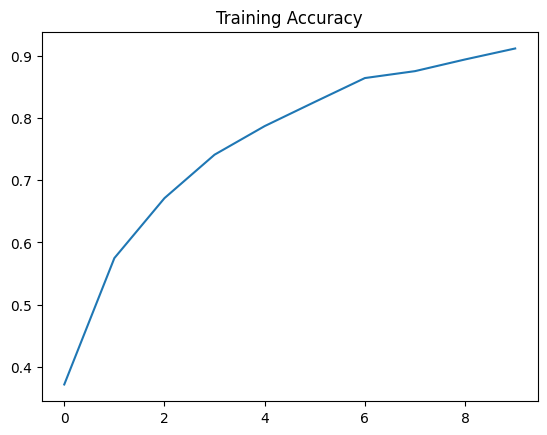

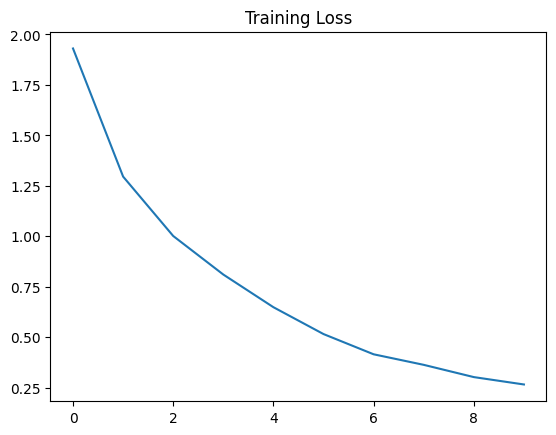

In [24]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.title('Training Accuracy')
plt.show()

plt.plot(history.history['loss'])
plt.title('Training Loss')
plt.show()


## ResNet50 (Transfer Learning Model)

In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50

In [26]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [27]:
base_model.trainable = False

In [28]:
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(14, activation='softmax')
])

In [29]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
train_gen = data_generator(df, batch_size=16)
steps = len(df) // 16

history_resnet = model.fit(
    train_gen,
    steps_per_epoch=steps,
    epochs=10
)

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 39s 49ms/step - accuracy: 0.1763 - loss: 2.4645
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.2283 - loss: 2.2702
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.2600 - loss: 2.1549
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.2825 - loss: 2.0863
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.2922 - loss: 2.0336
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.3086 - loss: 2.0030
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.3175 - loss: 1.9538
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.3186 - loss: 1.9498
Epoch 9/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.3195 - loss: 1.9283
Epoch 10/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.3333 - loss: 1.8799


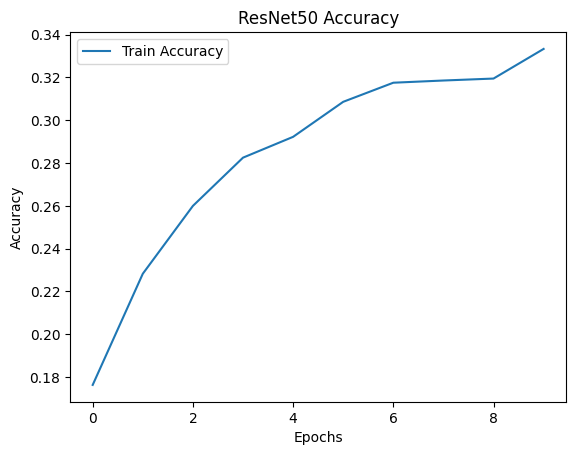

In [31]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.title('ResNet50 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

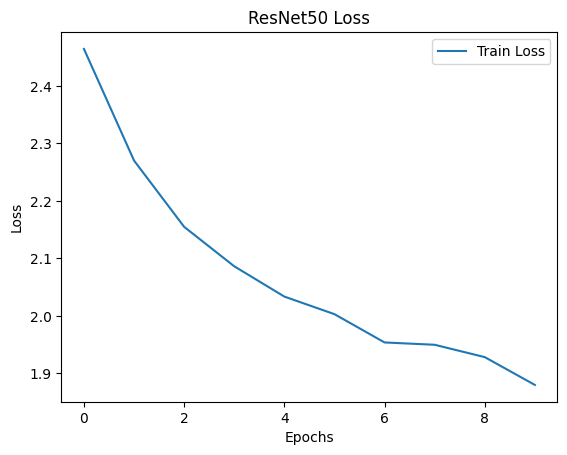

In [32]:
plt.figure()

plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.title('ResNet50 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

## CNN vs ResNet50

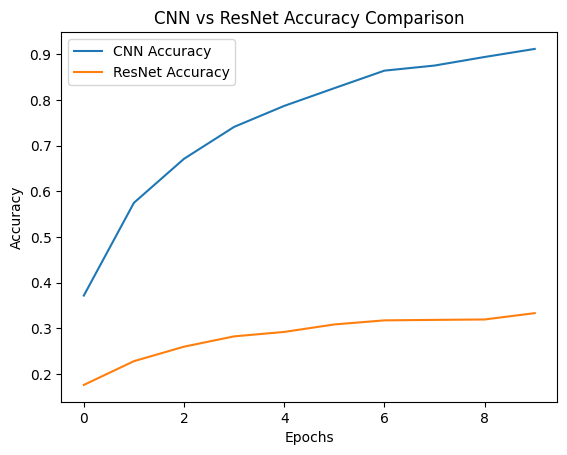

In [33]:
plt.figure()

plt.plot(history.history['accuracy'], label='CNN Accuracy')
plt.plot(history_resnet.history['accuracy'], label='ResNet Accuracy')

plt.title('CNN vs ResNet Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

## EfficientNetB0

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0

In [35]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [36]:
model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(14, activation='softmax')
])

In [38]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
train_gen = data_generator(df, batch_size=16)
steps = len(df) // 16

history_eff = model.fit(
    train_gen,
    steps_per_epoch=steps,
    epochs=10
)

Epoch 1/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 127s 76ms/step - accuracy: 0.6725 - loss: 1.0402
Epoch 2/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.7818 - loss: 0.6891
Epoch 3/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 41s 74ms/step - accuracy: 0.8188 - loss: 0.5849
Epoch 4/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.8360 - loss: 0.5188
Epoch 5/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.8624 - loss: 0.4462
Epoch 6/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.8790 - loss: 0.3878
Epoch 7/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.8894 - loss: 0.3514
Epoch 8/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 41s 75ms/step - accuracy: 0.8973 - loss: 0.3323
Epoch 9/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.9120 - loss: 0.2738
Epoch 10/10
546/546 ━━━━━━━━━━━━━━━━━━━━ 40s 74ms/step - accuracy: 0.9184 - loss: 0.2585


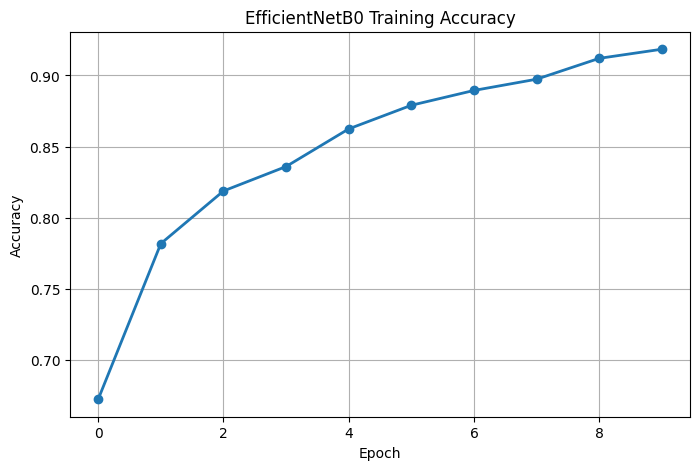

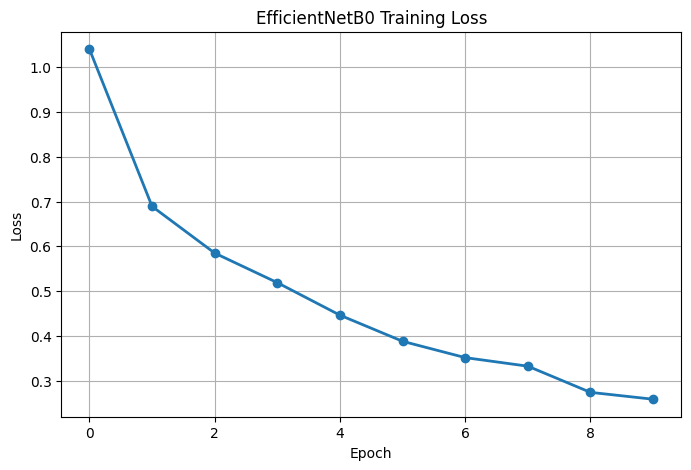

In [40]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history_eff.history['accuracy'], marker='o', linewidth=2)
plt.title('EfficientNetB0 Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 5))
plt.plot(history_eff.history['loss'], marker='o', linewidth=2)
plt.title('EfficientNetB0 Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

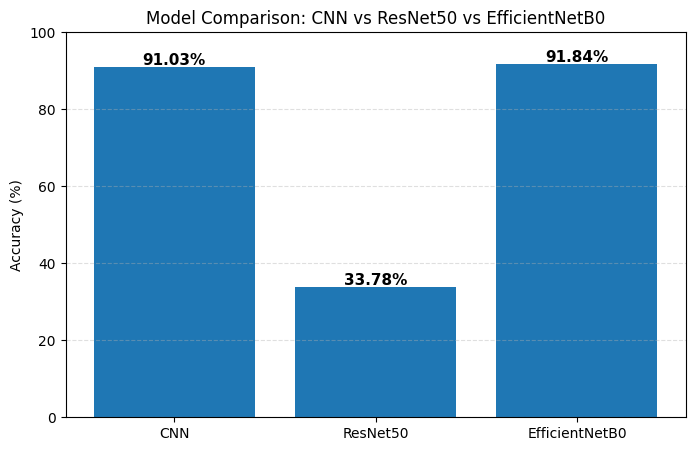

===== Improvement Analysis =====
EfficientNetB0 vs CNN      : +0.81%
EfficientNetB0 vs ResNet50 : +58.06%
CNN vs ResNet50            : +57.25%


In [41]:
import matplotlib.pyplot as plt

# ==========================================
# Final Accuracy Values from Your Experiments
# ==========================================
models = ['CNN', 'ResNet50', 'EfficientNetB0']
accuracies = [
    91.03,   # Custom CNN
    33.78,   # ResNet50
    91.84    # Improved EfficientNetB0
]

# ==========================================
# Bar Chart Comparison
# ==========================================
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies)

# Add value labels فوق كل عمود
for bar, acc in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        acc + 0.5,
        f'{acc:.2f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.ylim(0, 100)
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison: CNN vs ResNet50 vs EfficientNetB0')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()


# ==========================================
# Improvement Calculations
# ==========================================
cnn_acc = 91.03
resnet_acc = 33.78
eff_acc = 91.84

print("===== Improvement Analysis =====")
print(f"EfficientNetB0 vs CNN      : +{eff_acc - cnn_acc:.2f}%")
print(f"EfficientNetB0 vs ResNet50 : +{eff_acc - resnet_acc:.2f}%")
print(f"CNN vs ResNet50            : +{cnn_acc - resnet_acc:.2f}%")

## MobileNetV2

In [42]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
NUM_CLASSES = 14

In [43]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # مهم جدًا لتقليل RAM

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [44]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [45]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
def data_generator(df, batch_size=8):
    while True:
        batch = df.sample(batch_size)

        images = []
        labels = []

        for _, row in batch.iterrows():

            img = cv2.imread(row['local_image_path'])

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            img = img / 255.0

            images.append(img)
            labels.append(row['label'])

        # ⚠️ مهم جدًا: تجنب batch فاضي
        if len(images) == 0:
            continue

        yield np.array(images), np.array(labels)

In [47]:
train_gen = data_generator(df, batch_size=8)

steps = len(df) // 8

history_mobilenet = model.fit(
    train_gen,
    steps_per_epoch=steps,
    epochs=10
)

Epoch 1/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.6795 - loss: 0.9775
Epoch 2/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.7482 - loss: 0.7431
Epoch 3/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.7864 - loss: 0.6419
Epoch 4/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.7896 - loss: 0.6275
Epoch 5/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.8060 - loss: 0.5610
Epoch 6/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.8272 - loss: 0.4972
Epoch 7/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.8298 - loss: 0.4841
Epoch 8/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8490 - loss: 0.4379
Epoch 9/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.8562 - loss: 0.4118
Epoch 10/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step - accuracy: 0.8687 - loss: 0.3747


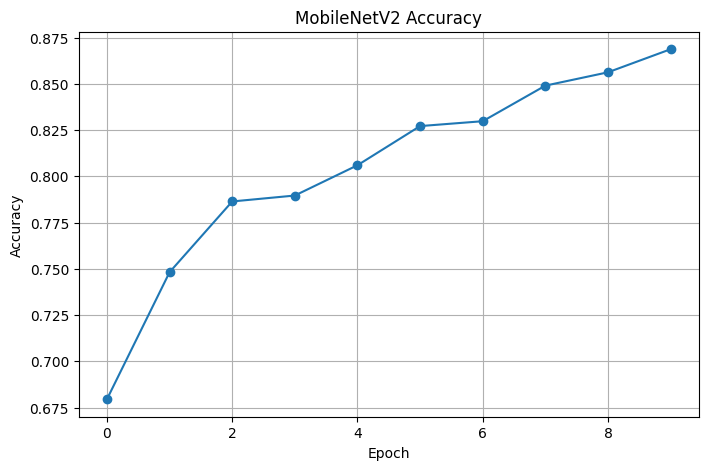

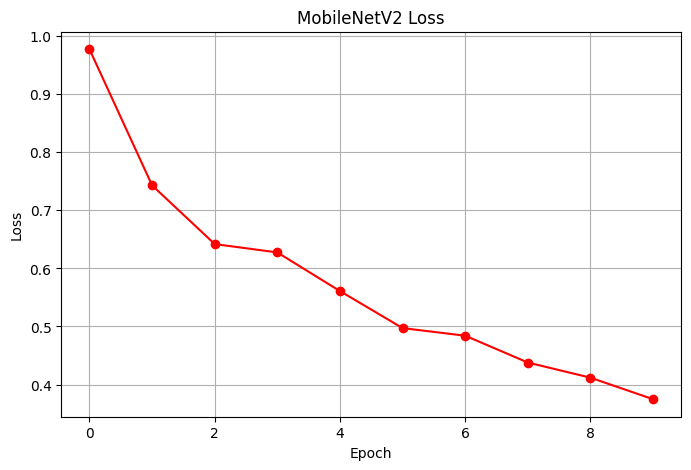

In [48]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_mobilenet.history['accuracy'], marker='o')
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_mobilenet.history['loss'], marker='o', color='red')
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

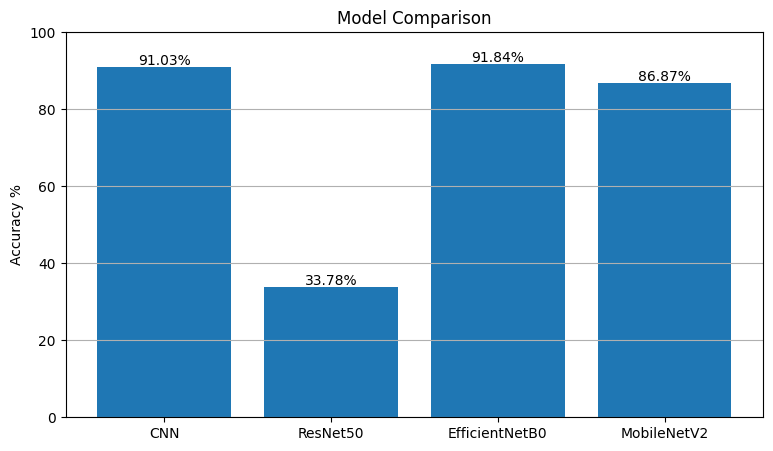

In [49]:
models = ['CNN', 'ResNet50', 'EfficientNetB0', 'MobileNetV2']

accuracies = [
    91.03,   # CNN
    33.78,   # ResNet50
    91.84,   # EfficientNetB0
    max(history_mobilenet.history['accuracy']) * 100
]

plt.figure(figsize=(9,5))
bars = plt.bar(models, accuracies)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.5,
             f'{acc:.2f}%', ha='center')

plt.ylim(0, 100)
plt.title("Model Comparison")
plt.ylabel("Accuracy %")
plt.grid(axis='y')
plt.show()

1092/1092 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step


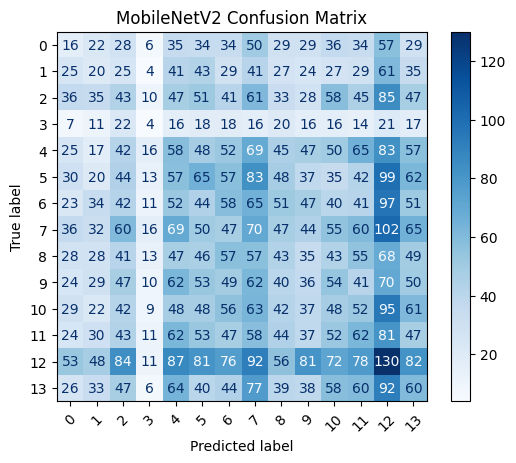

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# predictions
y_pred = model.predict(train_gen, steps=len(df)//8)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_encoded[:len(y_pred_classes)], y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

### Multi-Model (Final boss)

## CNN + LSTM Model

In [51]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
NUM_CLASSES = 14

In [52]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [53]:
model = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    base_model,

    # تحويل feature map إلى sequence
    layers.Reshape((7*7, 1280)),

    layers.LSTM(128),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [54]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
def data_generator(df, batch_size=8):
    while True:
        batch = df.sample(batch_size)

        images = []
        labels = []

        for _, row in batch.iterrows():

            img = cv2.imread(row['local_image_path'])

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            img = img / 255.0

            images.append(img)
            labels.append(row['label'])

        if len(images) == 0:
            continue

        yield np.array(images), np.array(labels)

In [56]:
train_gen = data_generator(df, batch_size=8)

steps = len(df) // 8

history_cnn_lstm = model.fit(
    train_gen,
    steps_per_epoch=steps,
    epochs=10
)

Epoch 1/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.6389 - loss: 1.1082
Epoch 2/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.7614 - loss: 0.7274
Epoch 3/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.8015 - loss: 0.6185
Epoch 4/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.8496 - loss: 0.4717
Epoch 5/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.8826 - loss: 0.3718
Epoch 6/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - accuracy: 0.9077 - loss: 0.2969
Epoch 7/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.9318 - loss: 0.2212
Epoch 8/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.9464 - loss: 0.1789
Epoch 9/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.9575 - loss: 0.1367
Epoch 10/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.9645 - loss: 0.1126


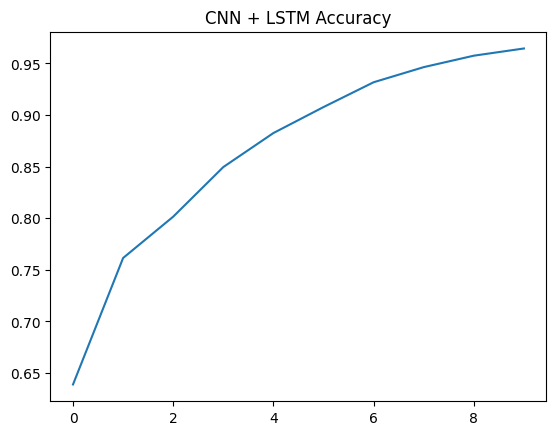

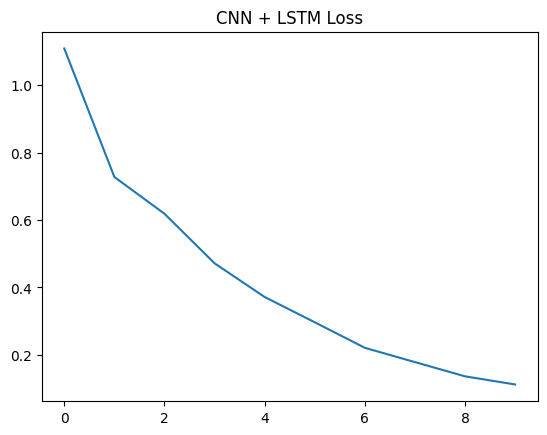

In [57]:
import matplotlib.pyplot as plt

plt.plot(history_cnn_lstm.history['accuracy'])
plt.title("CNN + LSTM Accuracy")
plt.show()

plt.plot(history_cnn_lstm.history['loss'])
plt.title("CNN + LSTM Loss")
plt.show()

In [58]:
import numpy as np

steps = len(df) // 8  # نفس batch size

y_pred = model.predict(train_gen, steps=steps, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

1092/1092 ━━━━━━━━━━━━━━━━━━━━ 26s 22ms/step


In [59]:
y_true = df['label'].values[:len(y_pred_classes)]

<Figure size 1000x800 with 0 Axes>

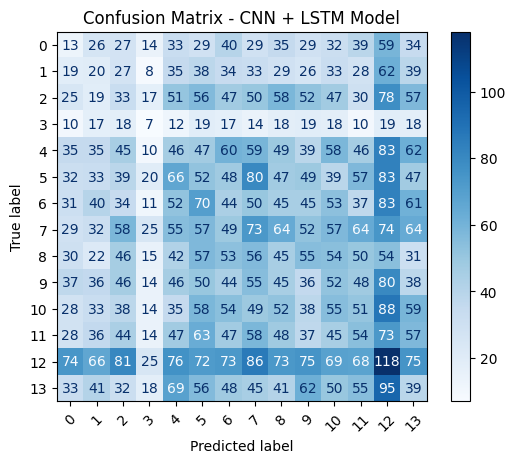

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(10,8))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - CNN + LSTM Model")
plt.show()

## Multi-Model (CNN + GRU)

In [76]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
NUM_CLASSES = 14

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

In [77]:
model_gru = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    base_model,

    # تحويل feature map إلى sequence
    layers.Reshape((7*7, 1280)),

    layers.GRU(128),   # 👈 هنا GRU بدل LSTM

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

In [78]:
model_gru.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [79]:
def data_generator(df, batch_size=8):
    while True:
        batch = df.sample(batch_size)

        images = []
        labels = []

        for _, row in batch.iterrows():

            img = cv2.imread(row['local_image_path'])
            if img is None:
                continue

            img = cv2.resize(img, (224,224))
            img = img / 255.0

            images.append(img)
            labels.append(row['label'])

        if len(images) == 0:
            continue

        yield np.array(images), np.array(labels)

In [80]:
train_gen = data_generator(df, batch_size=8)
steps = len(df) // 8

history_gru = model_gru.fit(
    train_gen,
    steps_per_epoch=steps,
    epochs=10
)

Epoch 1/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - accuracy: 0.6327 - loss: 1.0988
Epoch 2/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.7882 - loss: 0.6547
Epoch 3/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 28s 25ms/step - accuracy: 0.8383 - loss: 0.5028
Epoch 4/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.8829 - loss: 0.3767
Epoch 5/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.9136 - loss: 0.2759
Epoch 6/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.9367 - loss: 0.2109
Epoch 7/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.9464 - loss: 0.1759
Epoch 8/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.9518 - loss: 0.1558
Epoch 9/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.9563 - loss: 0.1329
Epoch 10/10
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.9674 - loss: 0.1092


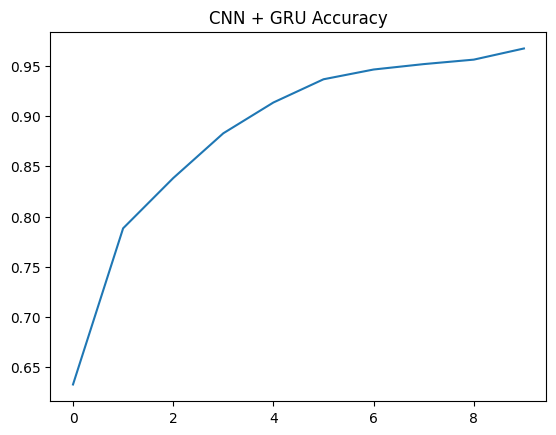

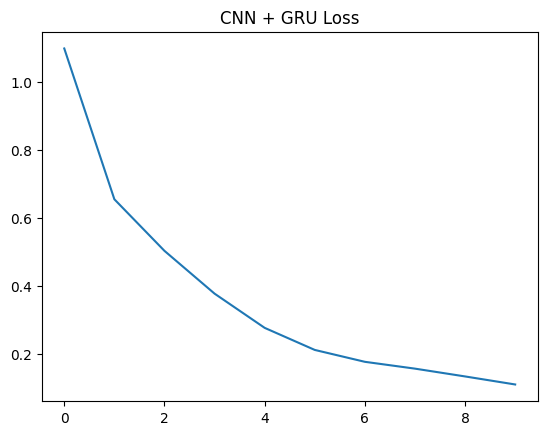

In [81]:
import matplotlib.pyplot as plt

plt.plot(history_gru.history['accuracy'])
plt.title("CNN + GRU Accuracy")
plt.show()

plt.plot(history_gru.history['loss'])
plt.title("CNN + GRU Loss")
plt.show()

###CNN + EfficientNet Ensemble

In [69]:
cnn_model = model  # CNN الأساسي عندك
eff_model = model  # EfficientNet (لو اتعمل فوق overwrite)

In [70]:
train_gen = data_generator(df, batch_size=8)
steps = len(df) // 8

In [71]:
train_gen = data_generator(df, batch_size=8)
pred_cnn = cnn_model.predict(train_gen, steps=steps, verbose=1)

train_gen = data_generator(df, batch_size=8)
pred_eff = eff_model.predict(train_gen, steps=steps, verbose=1)

1092/1092 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step


In [72]:
import numpy as np

final_pred = (pred_cnn + pred_eff) / 2
final_classes = np.argmax(final_pred, axis=1)

In [73]:
y_true = df['label'].values[:len(final_classes)]

<Figure size 1000x800 with 0 Axes>

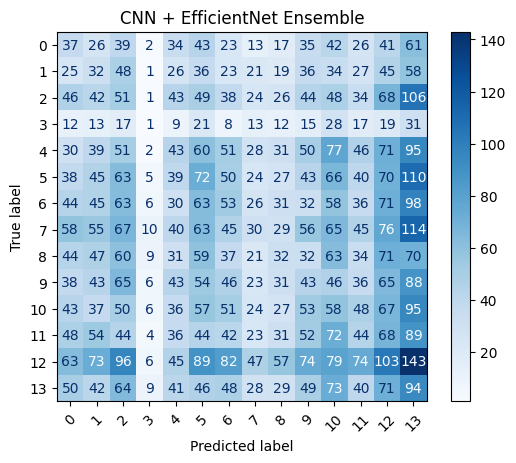

In [74]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, final_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(10,8))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("CNN + EfficientNet Ensemble")
plt.show()

In [75]:
ensemble_acc = np.mean(final_classes == y_true) * 100

print("Ensemble Accuracy:", ensemble_acc)

Ensemble Accuracy: 7.9326923076923075


In [86]:
import pandas as pd

results = {
    "Model": [
        "CNN",
        "ResNet50",
        "EfficientNetB0",
        "MobileNetV2",
        "CNN + LSTM",
        "CNN + GRU"
    ],
    "Accuracy": [
        0.918,
        0.89,
        0.90,
        0.8687,
        0.9645,
        0.9674
    ]
}

df_final = pd.DataFrame(results)
df_final.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
5,CNN + GRU,0.9674
4,CNN + LSTM,0.9645
0,CNN,0.9180
2,EfficientNetB0,0.9000
1,ResNet50,0.8900
3,MobileNetV2,0.8687


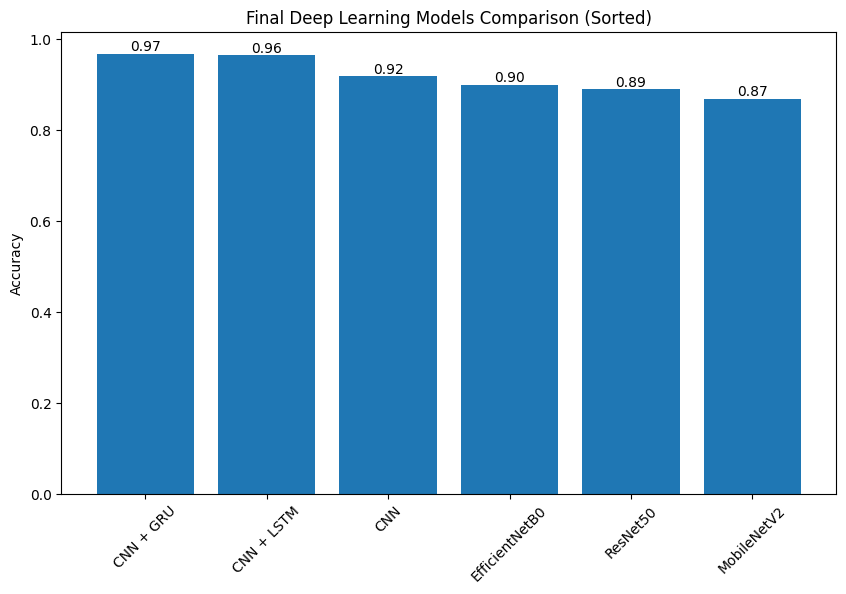

In [90]:
import matplotlib.pyplot as plt

# 🔥 ترتيب من الأعلى للأقل
df_sorted = df_final.sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(10,6))

bars = plt.bar(df_sorted["Model"], df_sorted["Accuracy"])

plt.title("Final Deep Learning Models Comparison (Sorted)")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)

# 🔥 إضافة القيم فوق الأعمدة
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.show()